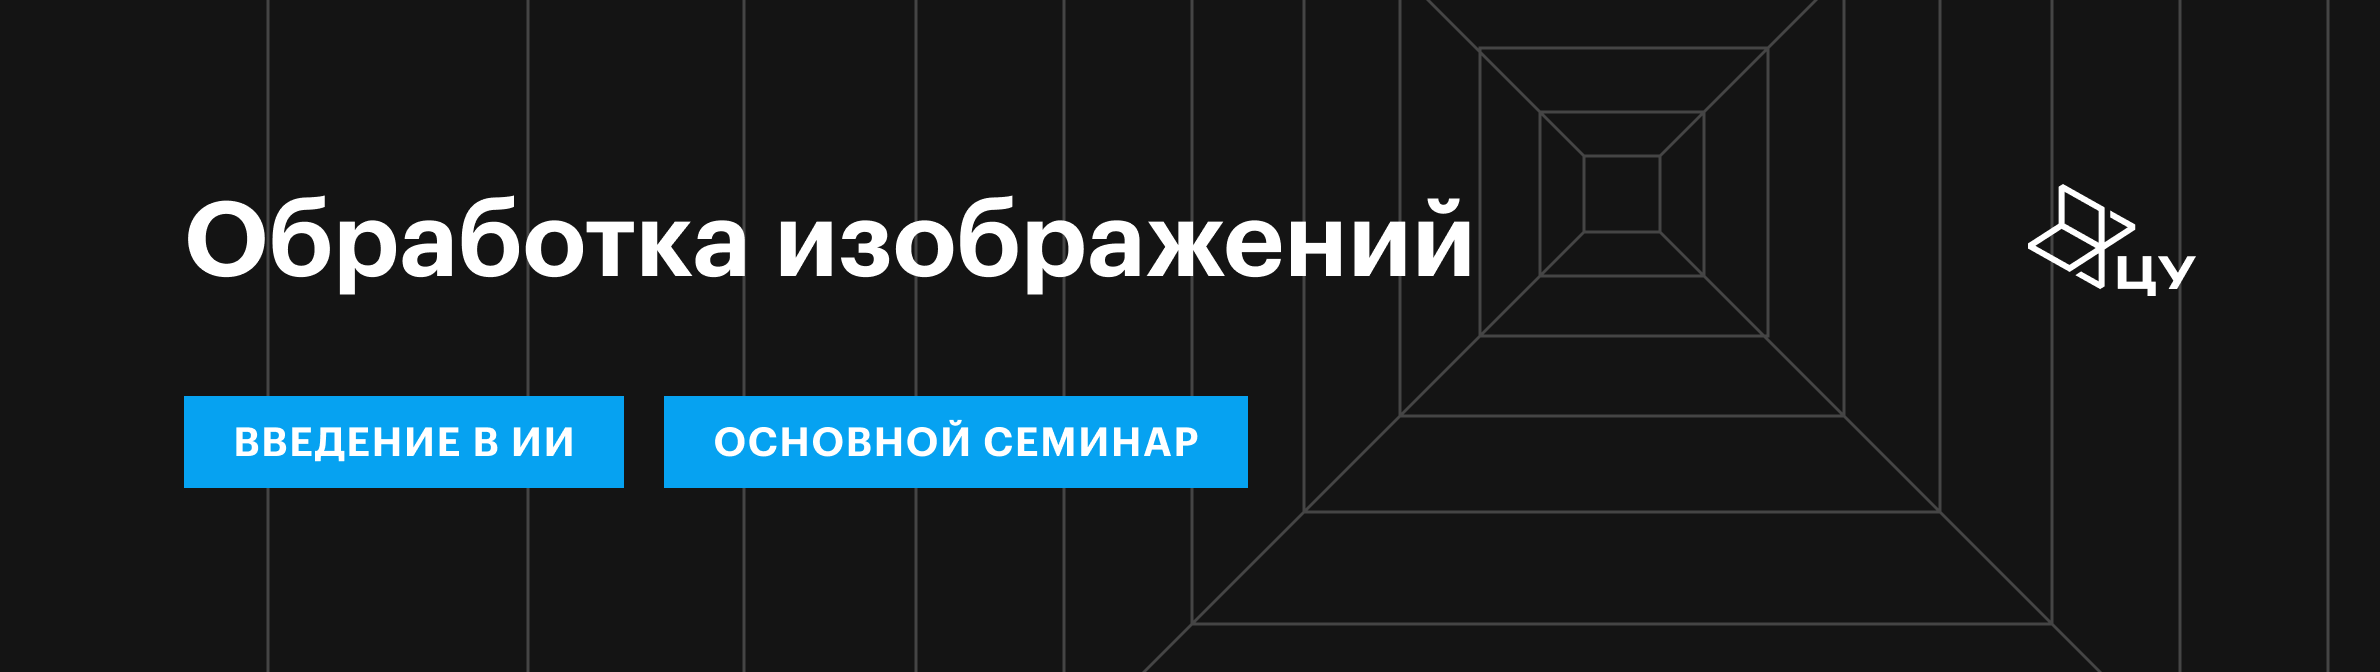

# Семинар по теме «Обработка изображений»

Сегодня ты познакомишься с основами обработки изображений в Python и обучишь простую модель классификации.

## Знакомство с cv2: чтение данных

Компьютерное зрение начинается с данных. Сначала загрузим небольшой [датасет](https://r0k.us/graphics/kodak/) изображений Kodak.


In [ ]:
!gdown 15uFEMCKuBQWRuTO32wSmxWQukBGtnADA
!unzip -q /content/kodak.zip
!rm /content/kodak.zip

Downloading...
From: https://drive.google.com/uc?id=15uFEMCKuBQWRuTO32wSmxWQukBGtnADA
To: /content/kodak.zip
100% 6.38M/6.38M [00:00<00:00, 40.8MB/s]


Отлично, теперь у нас есть изображения. Их можно открыть и насладиться красивыми пейзажами.

Дальше изображения нужно загрузить в программу и сохранить в виде массива. Для этого используют разные библиотеки, мы будем работать с opencv-python.

In [ ]:
import cv2

# Чтение с помощью cv2.imread
test_image = cv2.imread("kodak/kodim03.png")

Изображение — это массив пикселей. В каждом пикселе хранятся три числа: значения каналов R, G и B.

Функция `cv2.imread` загружает изображение и сохраняет его в таком формате:

In [ ]:
test_image.shape # С помощью метода shape можно узнать размерность массива

(512, 768, 3)

*   Первое число — количество пикселей по вертикали (высота изображения).
*   Второе число — количество пикселей по горизонтали (ширина изображения).
*   Третье число — количество каналов (три для цветного изображения: интенсивности каналов RGB).

Изображения хочется не только загружать, но и смотреть на них.

В библиотеке matplotlib есть встроенные функции для просмотра изображений.

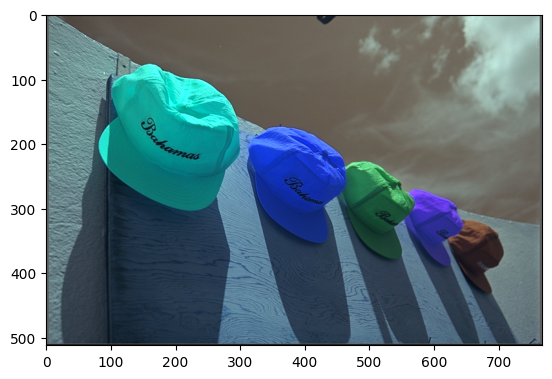

In [ ]:
import matplotlib.pyplot as plt

# Просмотр с помощью plt.imshow
plt.imshow(test_image)
plt.show()

**Вопрос.** Цвета на изображении выглядят странно: в реальности небо голубое, а на фото — коричневое.

В чём причина, и на каком этапе возникла ошибка?

### Ответ для семинариста
По изображению видно, что красный и синий каналы поменялись местами. Это происходит потому, что при чтении изображения библиотека opencv сохраняет каналы в порядке BGR, а не RGB.

Исправить это можно с помощью функции:

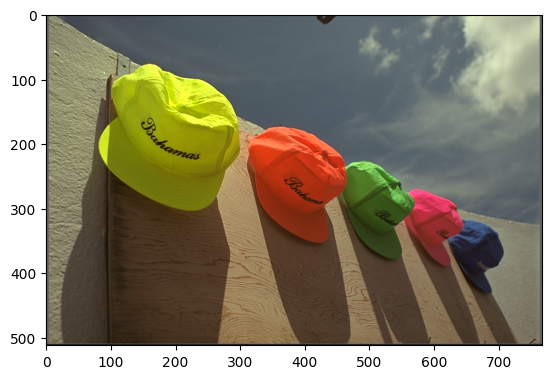

In [ ]:
# Функция cvtColor для работы с цветовыми пространствами
test_image = cv2.cvtColor(test_image, cv2.COLOR_BGR2RGB)

# Посмотрим на результат
plt.imshow(test_image)
plt.show()

Во многих задачах компьютерного зрения важнее не цвет, а яркость пикселей.

Чтобы получить яркость, изображение переводят в оттенки серого.

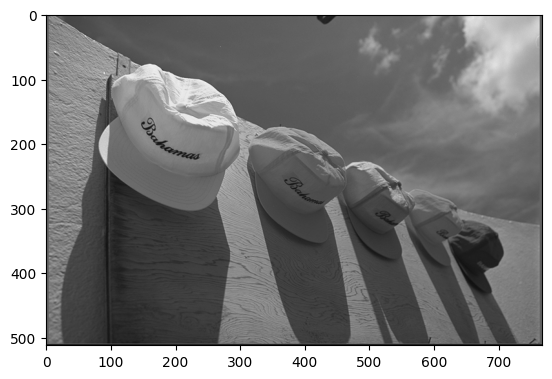

In [ ]:
# Функция cvtColor также используется для перевода в оттенки серого
test_gray = cv2.cvtColor(test_image, cv2.COLOR_RGB2GRAY)

# Посмотрим на результат
plt.imshow(test_gray, cmap='gray') # Карта отображения яркостей
plt.show()

PyTorch — библиотека для создания и обучения нейросетей. В ней данные хранятся в виде тензоров — многомерных массивов.

Поэтому перед обучением модели изображения нужно перевести из numpy- в torch-представление.

**Основные различия**

1. Порядок размерностей.
В numpy изображение имеет форму (H, W, C), где:
   *   H — высота изображения;
   *   W — ширина;
   *   C — число каналов. Для цветного изображения C = 3, у серого изображения этого измерения может не быть.

    В PyTorch порядок размерностей другой — (C, H, W).
    Если изображения объединяют в батч, появляется ещё одно измерение: (B, C, H, W), где B — размер батча.

2. Тип и диапазон значений.
После чтения через opencv интенсивности пикселей имеют тип `uint8`: это целые числа от 0 до 255. В PyTorch изображения обычно хранят в формате `float`: это действительные числа от 0 до 1.

### Задание 1. Миграция в torch
Напиши функцию, которая переводит изображение из numpy- в torch-представление, и функцию для обратного преобразования.


In [ ]:
import torch
import numpy as np

def numpy2torch(img):
    # Напиши код здесь
    pass

def torch2numpy(img):
    # Напиши код здесь
    pass

### Ответ для семинариста

In [ ]:
def numpy2torch(img):
    img = (img / 255) # нормируем на максимум
    img = torch.tensor(img, dtype=torch.float32)
    img = img.permute(2, 0, 1) # меняем каналы (H, W, C) -> (C, H, W)
    return img

def torch2numpy(img):
    if len(img.shape)==4:
        img = img.permute(0, 2, 3, 1) # меняем каналы (B, C, H, W) -> (B, H, W, C)
    else:
        img = img.permute(1, 2, 0) # меняем каналы (C, H, W) -> (H, W, C)

    img = img.numpy() # i'll be back
    img = (img * 255).astype(np.uint8) # переводим в инты

    return img

## Задание 2. Аугментация

В задачах компьютерного зрения важно увеличивать разнообразие данных. Для этого используют аугментацию изображений — преобразования, которые позволяют получить новые примеры из исходного датасета.

В этом задании нужно написать функции аугментации.

Сначала реализуй функцию, которая делит изображение на n случайных кропов заданного размера `crop_size` = (h, w).

На вход функция принимает изображение в формате тензора с размером (C, H, W).

На выходе возвращает тензор с размером (n, C, h, w).

Чтобы выбрать случайные координаты кропов, используй встроенный в PyTorch генератор случайных чисел `torch.randint`.

In [ ]:
def random_crop(img, crop_size, n_crops):
    # Напиши код здесь
    pass

### Ответ для семинариста

In [ ]:
def random_crop(img, crop_size, n_crops):
    c, h, w = img.shape
    crop_h, crop_w = crop_size

    # генерируем точки - верхние левые углы кропов
    xs = torch.randint(0, h-crop_h, (n_crops,))
    ys = torch.randint(0, w-crop_w, (n_crops,))

    # создаем массив кропов
    crops = torch.zeros((n_crops, c, crop_h, crop_w), dtype=img.dtype)
    for i in range(n_crops):
        x, y = xs[i], ys[i]
        crops[i] = img[:, x:x+crop_h, y:y+crop_w]

    return crops

Протестируем написанные функции.

In [ ]:
im_torch = numpy2torch(test_image) # В тензор
test_crops = random_crop(im_torch, (50, 50), 5) # Кропаем
test_crops_np = torch2numpy(test_crops) # В numpy-массив

### Задание 3. Не имей 100 plots, а имей 100 axis

Теперь нужно отобразить все изображения на одном рисунке.

Используй функцию `plt.subplots` из библиотеки matplotlib, чтобы вывести пять полученных кропов на одном полотне.

In [ ]:
# Напиши код здесь

### Ответ для семинариста

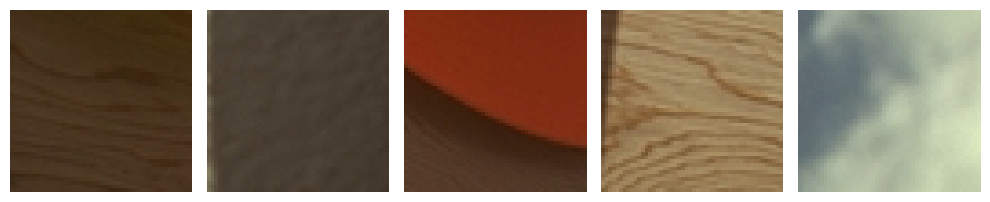

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(10, 10))

for i in range(5):
    axes[i].imshow(test_crops_np[i])
    axes[i].axis('off')

plt.tight_layout()
plt.show()

**Вопрос.** Какие геометрические преобразования изображений можно использовать для аугментации?

### Ответ для семинариста
Чаще всего используют:

*   горизонтальное и вертикальное отражение;
*   повороты на 90°, 180° и 270°.

Такие повороты не требуют интерполяции: прямоугольная сетка пикселей остаётся прямоугольной.

Более сложные преобразования - повороты на произвольный угол, сдвиги, скосы и растяжения - уже требуют интерполяции или дополнения изображения новыми пикселями.

### Задание 4. Один flip хорошо, а два лучше

Отрази изображение по вертикали и по горизонтали.

*   На вход функция принимает изображение в формате тензора с размером $(C, H, W)$ и тип отражения.
*   На выходе возвращает изображение того же размера, отражённое по соответствующей оси.

Подумай, какие преобразования можно реализовать in-place, то есть без копирования массива и выделения дополнительной памяти.


In [ ]:
def flip(img, type: str = "h"):
    # Напиши код здесь
    pass

### Ответ для семинариста

In [ ]:
def flip(img, type: str = "h"):
    c, h, w = img.shape

    # горизонтальное
    if type == "h":
        # меняем порядок местами
        h_inverse = torch.arange(h - 1, -1, -1)
        return img[:, h_inverse, :]
    # иначе - вертикльное
    w_inverse = torch.arange(w - 1, -1, -1)
    return img[:, :, w_inverse]


### Задание 5. Rotate, только rotate

Повернём изображение на угол, кратный 90°.

*   На вход функция принимает изображение в формате тензора с размером $(C, H, W)$ и угол поворота.
*   На выходе возвращает изображение, повёрнутое на заданный угол.

>**Подсказка.** При повороте на 90° и 270° высота и ширина меняются местами: $(H, W)$ → $(W, H)$. Используй `torch.permute()`, чтобы поменять размерности. Подумай, как связаны повороты и отражения.


In [ ]:
def rotate(img, angle: int = 0):
    # Напиши код здесь
    pass

### Ответ для семинариста

In [ ]:
def rotate(img, angle: int = 0):
    c, h, w = img.shape

    # простой кейс
    if angle == 0:
        return img

    # 90 и 270 - нужно менять размерность
    if angle == 90:
        return flip(img.permute(0, 2, 1), type='h')

    if angle == 270:
        return flip(img.permute(0, 2, 1), type='v')

    # просто отражаем по обеим осям
    if angle == 180:
        return flip(flip(img, type='h'), type='v')



Поворот на угол, кратный 90°, можно представить как комбинацию перестановки размерностей `permute` и отражения. Самый простой случай (если не считать поворота на 0°) — поворот на 180°. Он равен двум последовательным отражениям. Поворот на 90° — это комбинация `permute` и горизонтального отражения.


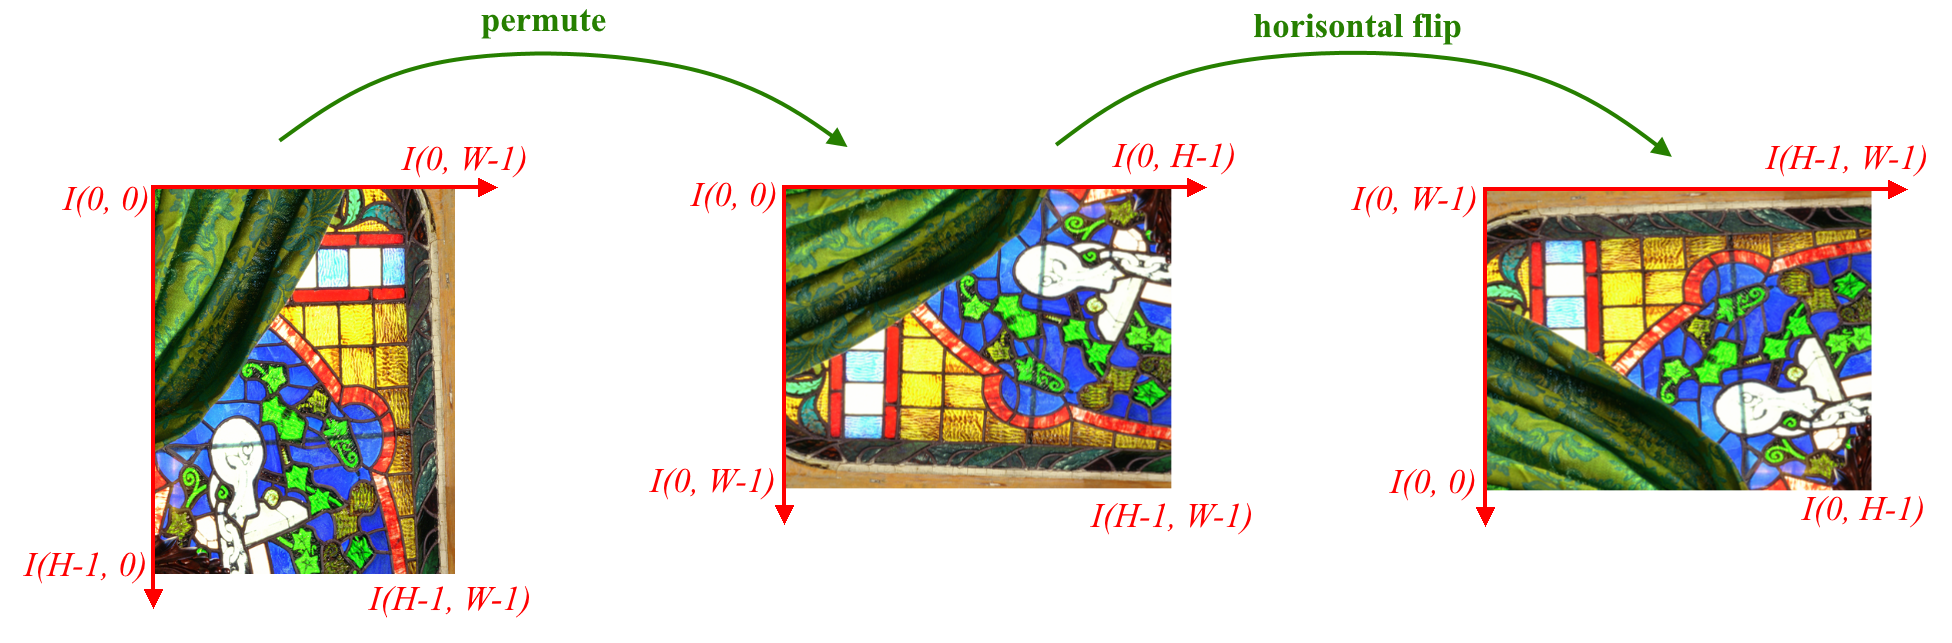

[Источник изображения](https://www4.comp.polyu.edu.hk/~cslzhang/CDM_Dataset.htm)

### Задание 6. Проверка преобразований
Протестируй реализованные преобразования на тестовом изображении. Используй код визуализации, написанный выше. Или выбери любое другое изображение из датасета.


In [ ]:
# Напиши код здесь

### Ответ для семинариста

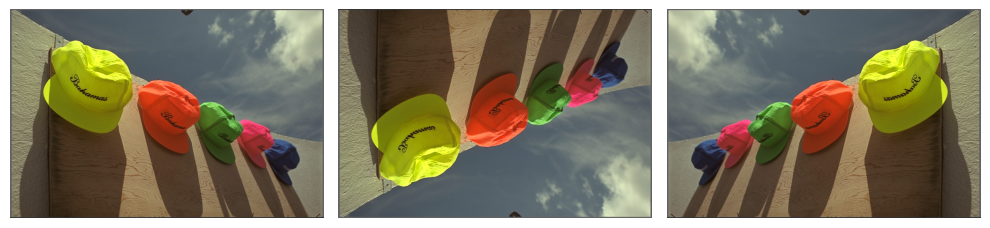

In [ ]:
flips = [im_torch, flip(im_torch, type='h'), flip(im_torch, type='v')]
flips_np = [torch2numpy(x) for x in flips]

# визуализация флипов
fig, axes = plt.subplots(1, 3, figsize=(10, 10))

for i in range(3):
    axes[i].imshow(flips_np[i])
    axes[i].axis('off')

plt.tight_layout()
plt.show()

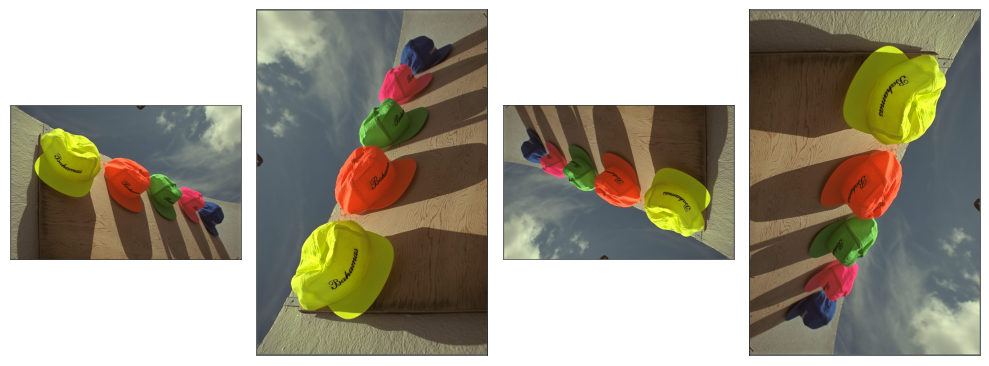

In [ ]:
rotates = [im_torch,
           rotate(im_torch, 90),
           rotate(im_torch, 180),
           rotate(im_torch, 270)]
rotates_np = [torch2numpy(x) for x in rotates]

# визуализация flip-ов
fig, axes = plt.subplots(1, 4, figsize=(10, 10))

for i in range(4):
    axes[i].imshow(rotates_np[i])
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## Классификация
Обучим модель логистической регрессии на двух датасетах.

* MNIST — датасет с изображениями рукописных цифр размером 28 × 28 пикселей. В этом задании используем только классы 0 и 1.
*  CIFAR-10 — датасет с цветными изображениями десяти разных классов размером 32 × 32 пикселя. Попробуем обучить модель различать кошек и собак.

**Вопрос.** Модель логистической регрессии принимает на вход векторы признаков, а изображение — это массив чисел.

Как подготовить изображения, чтобы обучить модель?

### Ответ для семинариста
Изображение можно развернуть в вектор признаков. Тогда значение интенсивности каждого пикселя станет отдельным признаком для модели.

$$
\textbf{X} = \left(
\begin{array}[ccc] \\
1 & 2 & 3 \\
4 & 5 & 6 \\
7 & 8 & 9
\end{array}
\right) \longrightarrow \textbf{x} = (1 \; 2 \; 3\; 4\; 5\; 6\; 7\; 8\; 9)
$$

В PyTorch и NumPy это можно сделать с помощью метода `flatten`.

Прежде чем обучить модель, нам нужно скачать данные и подготовить их в нужном формате. Загрузим часть датасета MNIST с диска.

In [ ]:
!gdown 1GpivR_5J4dLdrieemOA8bOSbJq3TPmt1
!unzip -q /content/mnist.zip
!rm /content/mnist.zip

Downloading...
From (original): https://drive.google.com/uc?id=1GpivR_5J4dLdrieemOA8bOSbJq3TPmt1
From (redirected): https://drive.google.com/uc?id=1GpivR_5J4dLdrieemOA8bOSbJq3TPmt1&confirm=t&uuid=ca4d0ded-16d1-4f6e-828b-fe77adaa16b3
To: /content/mnist.zip
100% 5.46M/5.46M [00:00<00:00, 38.1MB/s]


### Задание 7. Подготовка датасета

Твоя задача — написать функцию, которая собирает датасет для обучения.

Для этого нужно следующее.

1. Считать изображения из папки с помощью библиотек os и opencv.

2. Определить класс каждого изображения по имени файла.
Первая цифра в названии — это номер класса: 0 или 1. Например:
   *   `1_2134.png` — изображение с цифрой 1;
   *   `0_519.png` — изображение с цифрой 0.

3. Развернуть каждое изображение в вектор.

4. Собрать все изображения в матрицу $X$, а номера их классов — в вектор таргетов $y$.

In [ ]:
import os

def make_dataset(path):
    X = [] # Матрица данных
    y = [] # Вектор таргетов

    # Проходим по всем файлам в папке
    for img_path in sorted(os.listdir(path)):
        # Полный путь до файла можно найти таким образом
        full_path = os.path.abspath(os.path.join(path, img_path))

        # Напиши код здесь

    return X, y

### Ответ для семинариста

In [ ]:
def make_dataset(path):
    X = [] # матрица данных
    y = [] # вектор таргетов

    # проходим по всем файлам в папке
    for img_name in sorted(os.listdir(path)):
        # полный путь до файла можно найти таким образом
        full_path = os.path.abspath(os.path.join(path, img_name))

        # читаем изображение
        img = cv2.imread(full_path, cv2.IMREAD_GRAYSCALE)

        img = img.flatten() # разворачиваем изображение в вектор
        img = (img / 255).astype(np.float32) # нормируем данные на максимум

        # узнать класс можно, например, разделив имя по символу "_"
        target = int(img_name.split("_")[0])

        # добавляем данные в X и y
        X.append(img)
        y.append(target)

    return np.array(X), np.array(y)

Теперь дело за малым: разделить данные на обучающую и тестовую выборки.

In [ ]:
from sklearn.model_selection import train_test_split

X, y = make_dataset("/content/mnist")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Посмотрим на примеры данных из датасета, используя код для визуализации кропов.

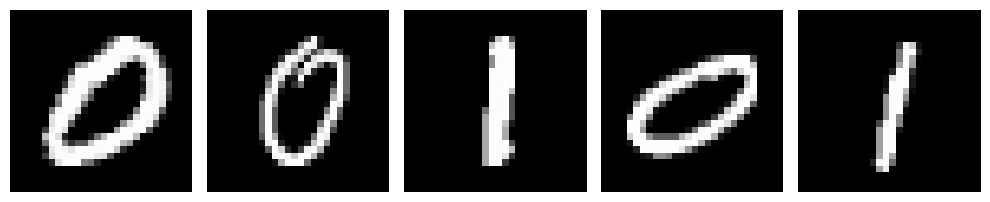

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(10, 10))

for i in range(5):
    axes[i].imshow(X_test[i].reshape((28, 28)), cmap='gray')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

### Задание 8. Как модель назовёшь, так она и обучится

Твоя задача — обучить модель логистической регрессии.

Эту модель изучали в первой части курса, поэтому воспользуйся готовой реализацией из библиотеки sklearn.

In [ ]:
# Напиши код здесь

### Ответ для семинариста

In [ ]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(
    random_state=42,
    max_iter=100,
    solver='lbfgs',
    verbose=0
)

In [ ]:
logreg.fit(X_train, y_train)

LogisticRegression(random_state=42)

In [ ]:
y_predict = logreg.predict(X_test)

Посмотрим на качество классификации с помощью метода `classification_report` из библиотеки sklearn.

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1226
           1       1.00      1.00      1.00      1307

    accuracy                           1.00      2533
   macro avg       1.00      1.00      1.00      2533
weighted avg       1.00      1.00      1.00      2533



**Вопрос.** Такая простая модель, как линейная регрессия, хорошо справилась с задачей.
Как думаешь, почему?

### Ответ для семинариста

Всё дело в том, как устроены данные:

*  Простая геометрия изображений.
Например, пиксели в центре изображения чаще относятся к цифре 1, а по краям - к цифре 0.
*   Простая структура изображений.
В данных почти нет лишней информации: это белые цифры на чёрном фоне.

## Работа с CIFAR-10

Повышаем планку: теперь проделаем то же самое для датасета CIFAR-10. Сначала прочитаем данные с диска.


In [ ]:
!gdown 1_DP422K4g547EJt1Dr5FLf3FK-B3arch
!unzip -q /content/cifar.zip
!rm /content/cifar.zip

Downloading...
From (original): https://drive.google.com/uc?id=1_DP422K4g547EJt1Dr5FLf3FK-B3arch
From (redirected): https://drive.google.com/uc?id=1_DP422K4g547EJt1Dr5FLf3FK-B3arch&confirm=t&uuid=e7d05a32-5c39-4247-8f27-bd4eb9ec78c3
To: /content/cifar.zip
100% 26.6M/26.6M [00:00<00:00, 60.0MB/s]


Данные в том же формате, поэтому воспользуемся функцией `make_dataset` и визуализируем.

In [ ]:
X, y = make_dataset("/content/cifar")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

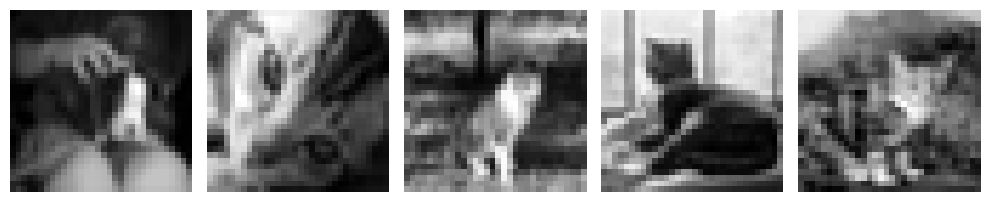

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(10, 10))

for i in range(5):
    axes[i].imshow(X_test[i].reshape((32, 32)), cmap='gray')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

Разобраться непросто. Проверим, как с этим справится модель.

In [ ]:
logreg.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(random_state=42)

In [ ]:
y_predict = logreg.predict(X_test)

In [ ]:
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.57      0.54      0.55      1012
           1       0.55      0.59      0.57       988

    accuracy                           0.56      2000
   macro avg       0.56      0.56      0.56      2000
weighted avg       0.56      0.56      0.56      2000



**Вопрос.** Почему логистическая регрессия не может различить братьев наших меньших на изображении?

### Ответ для семинариста

Как и в случае с MNIST, всё дело в данных.

Логистическая регрессия предполагает линейную разделимость классов, а датасет CIFAR-10 этому условию не удовлетворяет. У изображений более сложная пространственная структура, поэтому простая линейная модель работает хуже.